<a href="https://colab.research.google.com/github/ranimiftah12345678/PCVK26_22_Ranimiftah/blob/main/Modul6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Rani Miftahus Saadah'
NIM  = '24410720057'
N     = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L':    2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Rani Miftahus Saadah
NIM    : 24410720057 | N = 57
bins   : 16
clip   : 2.0
tile   : 3
L      : 2
WAKTU  : 2026-10-03 16:53:52 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 24f36224690f78d6


##PRAKTIKUM FILTER

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [10]:
BASE = '/content/drive/MyDrive/PCVK 244107020057'
IMAGES_BASE = BASE

In [11]:
# FUNGSI KONVOLUSI
def convolution2d(image, kernel, stride, padding):
    # Ubah ke float agar hasil perhitungan tidak terpotong
    image = np.array(image, dtype=np.float64)
    kernel = np.array(kernel, dtype=np.float64)
    kh, kw = kernel.shape

    # Tambahkan padding bernilai 0 di sekeliling citra
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)),
                       mode='constant', constant_values=0)

    H, W = image.shape

    # Ukuran citra hasil konvolusi
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    result = np.zeros((out_h, out_w), dtype=np.float64)

    # Geser kernel pada citra
    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            # Jumlah perkalian tiap elemen kernel dengan piksel di bawahnya
            result[i, j] = np.sum(region * kernel)

    return result

In [12]:
img = cv.imread(os.path.join(IMAGES_BASE, 'mandrill.tiff'))
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

Menentukan kernel yang akan digunakan

In [13]:
# image sharpen
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

Memanggil fungsi konvolusi dan menerapkan setiap filter yang telah digunakan

Ukuran citra asli  : (512, 512)
Ukuran hasil       : (514, 514)


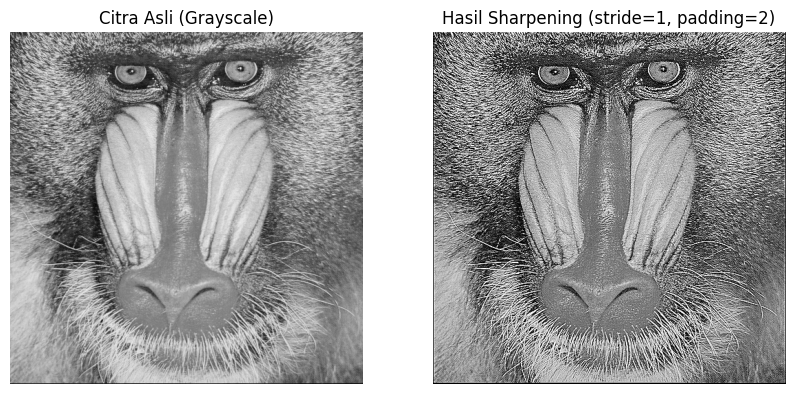

In [14]:
# stride=1, padding=2
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

print("Ukuran citra asli  :", img_gray.shape)
print("Ukuran hasil       :", hasil_sharpen.shape)

# Nilai hasil bisa < 0 atau > 255, jadi di-clip lalu diubah ke uint8
hasil_sharpen_u8 = np.clip(hasil_sharpen, 0, 255).astype(np.uint8)

# Tampilkan berdampingan
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_sharpen_u8, cmap='gray')
plt.title('Hasil Sharpening (stride=1, padding=2)')
plt.axis('off')

plt.show()

1. Sharpen

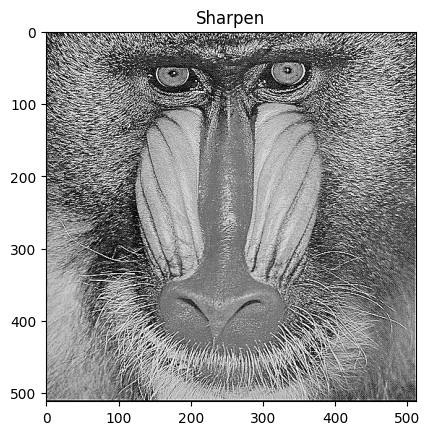

In [15]:
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 1)
hasil_sharpen = np.clip(hasil_sharpen, 0, 255).astype(np.uint8)

plt.imshow(hasil_sharpen, cmap='gray')
plt.title('Sharpen')
plt.show()

2. Emboss

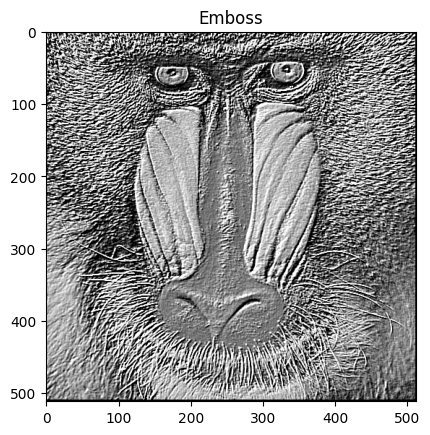

In [16]:
kernel_emboss = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])

hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 1)
hasil_emboss = np.clip(hasil_emboss, 0, 255).astype(np.uint8)

plt.imshow(hasil_emboss, cmap='gray')
plt.title('Emboss')
plt.show()

3. Left Sobel Edge Detection

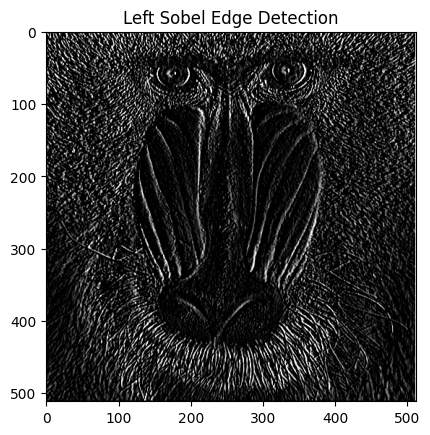

In [17]:
kernel_sobel_left = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

hasil_sobel = convolution2d(img_gray, kernel_sobel_left, 1, 1)
hasil_sobel = np.clip(hasil_sobel, 0, 255).astype(np.uint8)

plt.imshow(hasil_sobel, cmap='gray')
plt.title('Left Sobel Edge Detection')
plt.show()

4. Canny Edge Detection

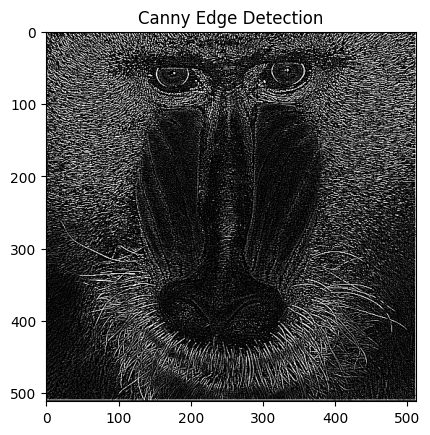

In [18]:
kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])

hasil_canny = convolution2d(img_gray, kernel_canny, 1, 1)
hasil_canny = np.clip(hasil_canny, 0, 255).astype(np.uint8)

plt.imshow(hasil_canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.show()

5. 21x21 Gaussian Blur

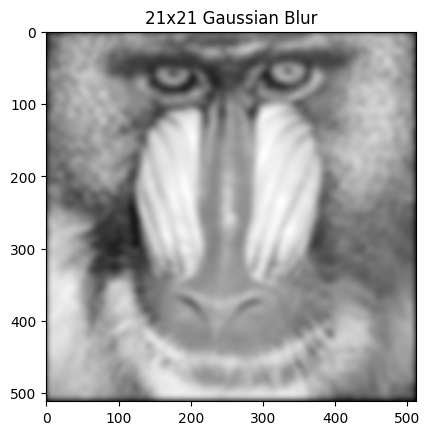

In [19]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

# padding = 10 agar ukuran hasil sama dengan citra asli (21 // 2)
hasil_gauss = convolution2d(img_gray, gauss_kernel, 1, 10)
hasil_gauss = np.clip(hasil_gauss, 0, 255).astype(np.uint8)

plt.imshow(hasil_gauss, cmap='gray')
plt.title('21x21 Gaussian Blur')
plt.show()

## FILTER LIBRARY DAN FILTER MODERN

Percobaan 1:

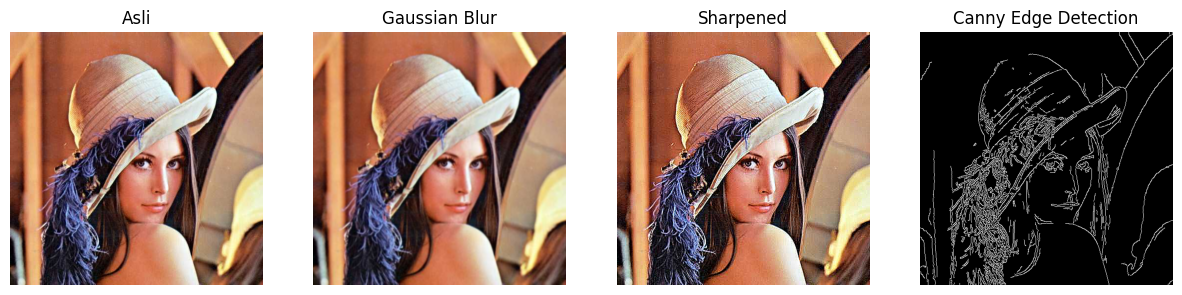

In [20]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK 244107020057/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

Percobaan 2:

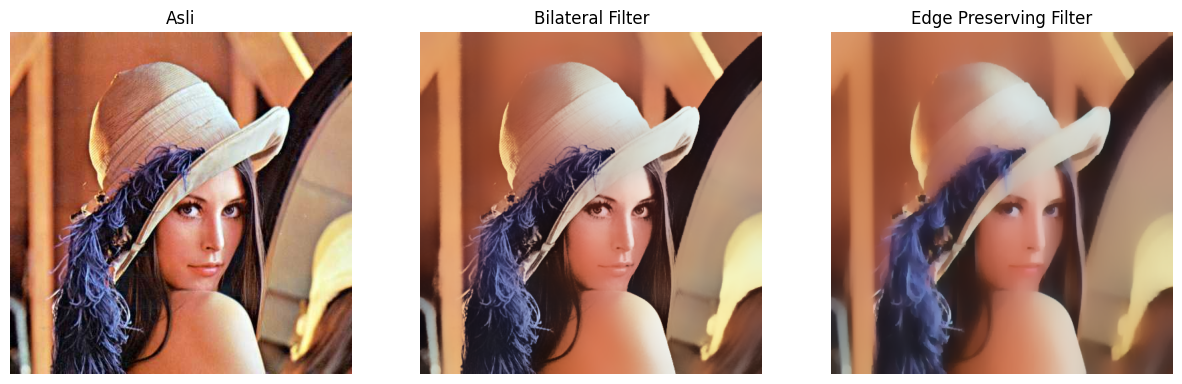

In [21]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

Percobaan 3:

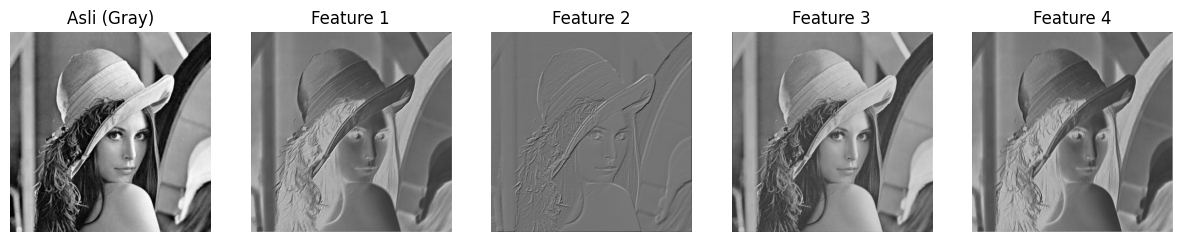

In [22]:
# Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Percobaan 4:

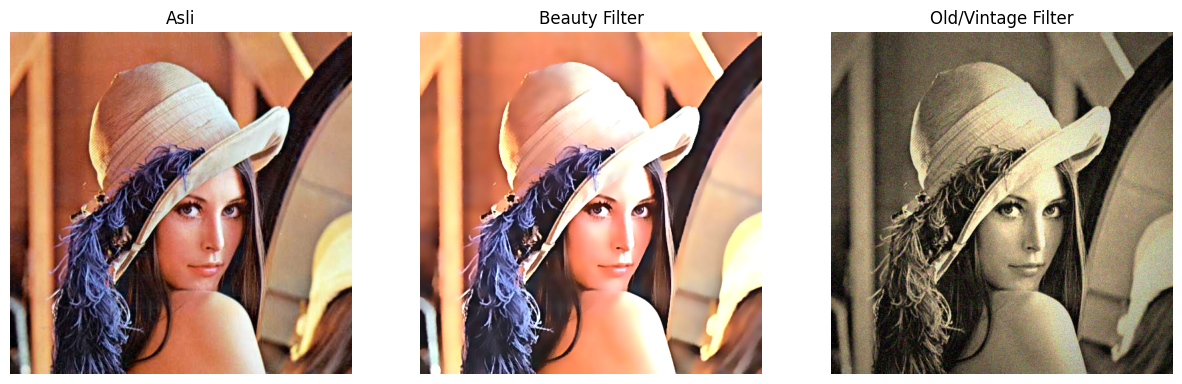

In [25]:
# =====================
# 1. Beauty Filter
# =====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2   # contrast
beta = 15     # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =====================
# 2. Old/Vintage Filter
# =====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img],
                  ["Asli", "Beauty Filter", "Old/Vintage Filter"])

Percobaan 5:

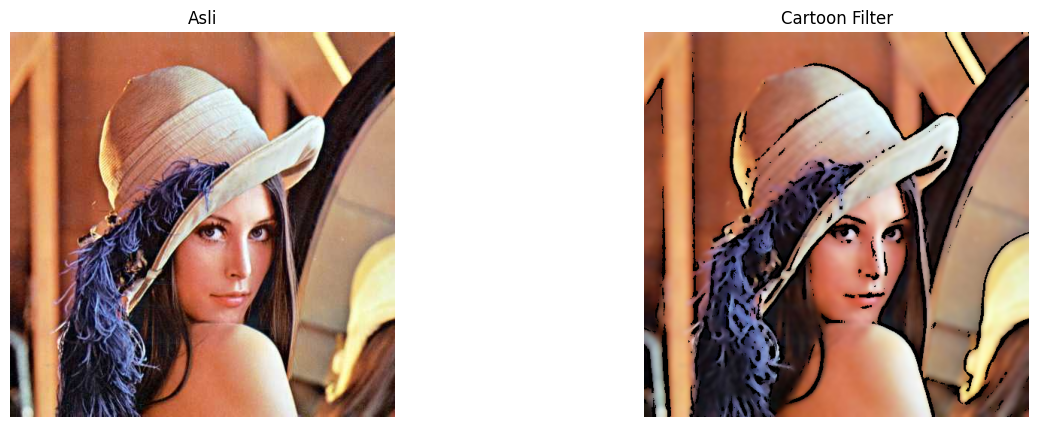

In [26]:
# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

Percobaan 6:

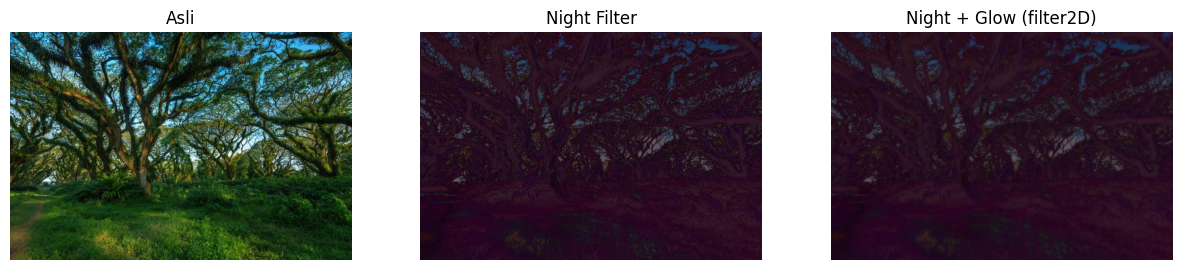

In [27]:
# Night Filter
img = cv.imread(os.path.join(BASE, 'djawatan.jpg'))
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))   # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

Percobaan 7:

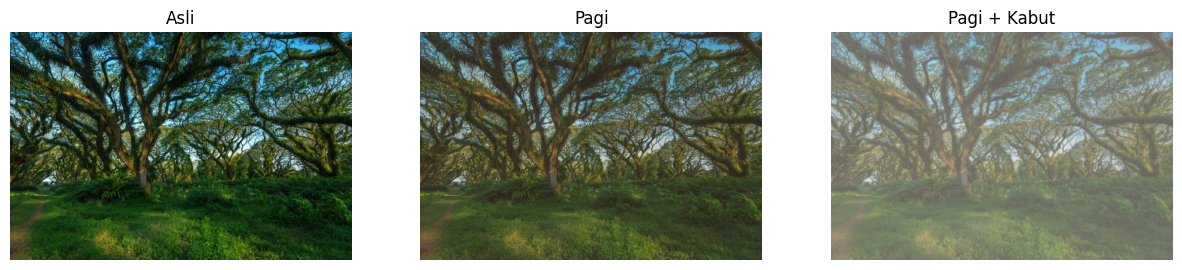

In [28]:
# Filter Suasana Pagi dan Kabut
# =========================
# Step 1: Kurangi kontras & cerahkan
# =========================
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =========================
warm_tint = np.full_like(soft, (40, 70, 120))   # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T   # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

##Tugas Praktikum

#1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and Pepper”

a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).

In [29]:
def tambah_salt_pepper(citra, jumlah=0.05, seed=42):
    """
    jumlah = proporsi piksel yang terkena noise (0.05 = 5%)
    Separuh jadi putih (salt, 255), separuh jadi hitam (pepper, 0)
    """
    rng = np.random.default_rng(seed)
    noisy = citra.copy()
    total = citra.size

    n_salt = int(total * jumlah / 2)
    n_pepper = int(total * jumlah / 2)

    # Salt (putih)
    y = rng.integers(0, citra.shape[0], n_salt)
    x = rng.integers(0, citra.shape[1], n_salt)
    noisy[y, x] = 255

    # Pepper (hitam)
    y = rng.integers(0, citra.shape[0], n_pepper)
    x = rng.integers(0, citra.shape[1], n_pepper)
    noisy[y, x] = 0

    return noisy

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)   # pastikan citra grayscale
img_noisy = tambah_salt_pepper(img_gray, jumlah=0.05)

b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).

In [33]:
# Mean filter 3x3 (blur biasa)
mean_filtered = cv.blur(img_noisy, (3, 3))

# Median filter 3x3
median_filtered = cv.medianBlur(img_noisy, 3)

c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus
noise tersebut dibanding Mean Filter

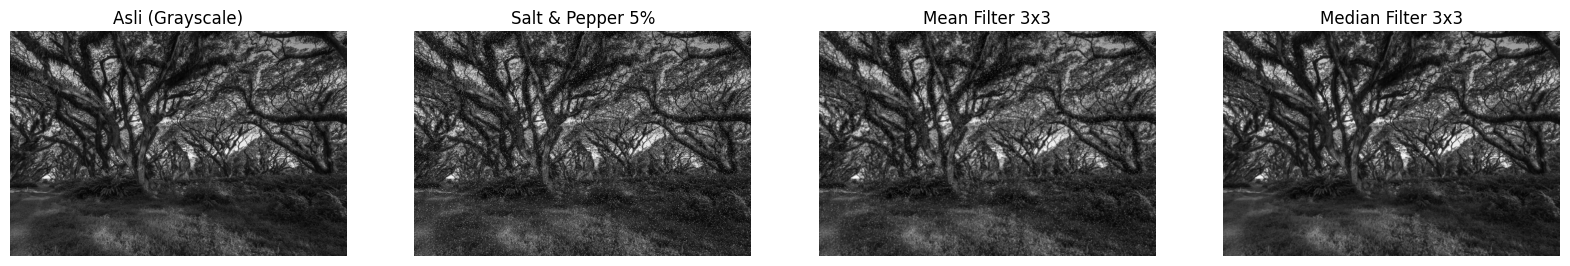

Citra                       MSE    PSNR (dB)
Noisy                   1094.10        17.74
Mean Filter 3x3          563.57        20.62
Median Filter 3x3        450.73        21.59


In [34]:
show_side_by_side([img_gray, img_noisy, mean_filtered, median_filtered],
                  ["Asli (Grayscale)", "Salt & Pepper 5%", "Mean Filter 3x3", "Median Filter 3x3"],
                  figsize=(20, 5))

# Perbandingan kuantitatif terhadap citra asli
def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)

def psnr(a, b):
    m = mse(a, b)
    return float('inf') if m == 0 else 10 * np.log10(255**2 / m)

print(f"{'Citra':20s} {'MSE':>10s} {'PSNR (dB)':>12s}")
for nama, hasil in [("Noisy", img_noisy),
                    ("Mean Filter 3x3", mean_filtered),
                    ("Median Filter 3x3", median_filtered)]:
    print(f"{nama:20s} {mse(img_gray, hasil):10.2f} {psnr(img_gray, hasil):12.2f}")

### a. Penambahan noise
Noise salt and pepper ditambahkan pada citra grayscale sebanyak 5% dari jumlah piksel. Separuhnya diubah menjadi putih (255, salt) dan separuhnya menjadi hitam (0, pepper).

### b. Penerapan filter
Diterapkan Mean Filter 3x3 dan Median Filter 3x3 pada citra yang sama.

### c. Analisis: Mengapa Median Filter lebih bersih?

**Mean Filter** menghitung rata-rata 9 piksel dalam jendela 3x3. Noise salt (255) dan pepper (0) adalah nilai ekstrem (outlier). Ketika ikut dirata-rata, outlier tidak hilang, tetapi menyebar ke piksel di sekitarnya. Hasilnya berupa bercak abu-abu yang buram, dan tepi objek ikut mengabur karena filter ini memperhalus semua perbedaan intensitas.

**Median Filter** mengurutkan 9 nilai piksel dalam jendela lalu mengambil nilai tengahnya (urutan ke-5). Nilai ekstrem 0 atau 255 selalu berada di ujung urutan sehingga hampir tidak pernah terpilih sebagai median. Piksel yang terkena noise diganti dengan nilai tetangga yang wajar, sehingga noise hilang tanpa mengotori piksel di sekitarnya.

| Aspek | Mean Filter | Median Filter |
|---|---|---|
| Jenis operasi | Linear (rata-rata) | Non-linear (nilai tengah) |
| Terhadap outlier | Sensitif, noise menyebar | Tahan, outlier diabaikan |
| Tepi objek | Mengabur | Relatif terjaga |
| Hasil pada salt and pepper | Bintik redup dan citra blur | Bersih dan tajam |
| PSNR | Lebih rendah | Lebih tinggi |

### Kesimpulan
Untuk noise salt and pepper, **Median Filter jauh lebih efektif** karena mengambil nilai tengah yang tidak terpengaruh outlier, sedangkan Mean Filter memasukkan outlier ke dalam perhitungan rata-rata. Mean Filter lebih cocok untuk noise yang tersebar merata dan tidak ekstrem, misalnya noise Gaussian.

#2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.

In [35]:
# Sharpening kernel 3x3 (jumlah elemen = 1)
kernel_sharp_3 = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float64)

# Sharpening kernel 5x5 (jumlah elemen = 8, dibagi 8 agar total = 1)
kernel_sharp_5 = np.array([[-1, -1, -1, -1, -1],
                           [-1,  2,  2,  2, -1],
                           [-1,  2,  8,  2, -1],
                           [-1,  2,  2,  2, -1],
                           [-1, -1, -1, -1, -1]], dtype=np.float64) / 8

print("Jumlah kernel 3x3:", kernel_sharp_3.sum())
print("Jumlah kernel 5x5:", kernel_sharp_5.sum())

Jumlah kernel 3x3: 1.0
Jumlah kernel 5x5: 1.0


b. Terapkan pada citra yang sedikit buram (blurry).

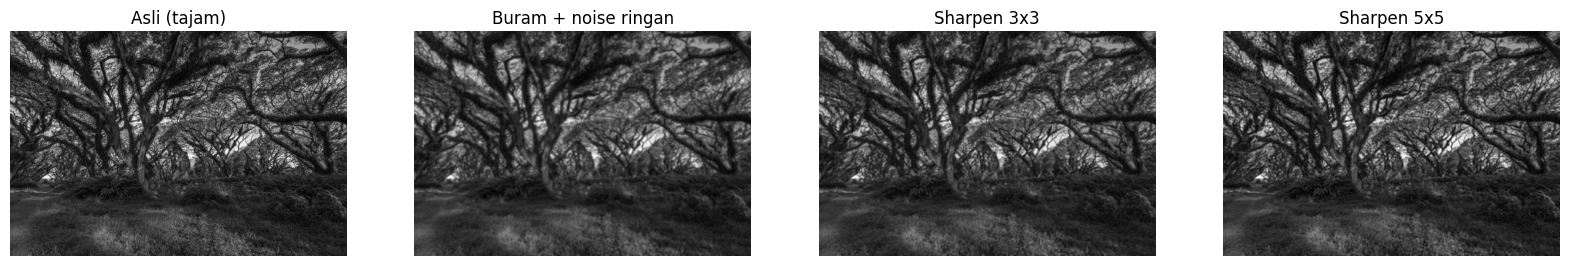

In [36]:
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)     # citra asli (acuan tajam)

# Buat citra buram + noise ringan
img_blur = cv.GaussianBlur(img_gray, (7, 7), 2)
rng = np.random.default_rng(0)
noise = rng.normal(0, 3, img_blur.shape)
img_blur = np.clip(img_blur.astype(np.float64) + noise, 0, 255).astype(np.uint8)

# Terapkan kernel (cv.filter2D agar cepat)
hasil_3 = cv.filter2D(img_blur, -1, kernel_sharp_3)
hasil_5 = cv.filter2D(img_blur, -1, kernel_sharp_5)

show_side_by_side([img_gray, img_blur, hasil_3, hasil_5],
                  ["Asli (tajam)", "Buram + noise ringan", "Sharpen 3x3", "Sharpen 5x5"],
                  figsize=(20, 5))

c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang
dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

In [37]:
def kejelasan_tepi(citra):
    """Variance of Laplacian (makin besar = tepi makin jelas)"""
    return cv.Laplacian(citra, cv.CV_64F).var()

def gradien_rata(citra):
    """Rata-rata magnitudo gradien Sobel"""
    gx = cv.Sobel(citra, cv.CV_64F, 1, 0, ksize=3)
    gy = cv.Sobel(citra, cv.CV_64F, 0, 1, ksize=3)
    return np.mean(np.sqrt(gx**2 + gy**2))

# Area datar (gradien kecil) dari citra buram, dipakai untuk mengukur noise
gx = cv.Sobel(img_blur, cv.CV_64F, 1, 0, ksize=3)
gy = cv.Sobel(img_blur, cv.CV_64F, 0, 1, ksize=3)
grad = np.sqrt(gx**2 + gy**2)
area_datar = grad < np.percentile(grad, 30)

def kadar_noise(citra):
    """Std komponen frekuensi tinggi di area datar (makin besar = makin berisik)"""
    halus = cv.GaussianBlur(citra, (5, 5), 1).astype(np.float64)
    resid = citra.astype(np.float64) - halus
    return resid[area_datar].std()

def psnr(a, b):
    m = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float('inf') if m == 0 else 10 * np.log10(255**2 / m)

print(f"{'Citra':22s} {'Tepi (VarLap)':>14s} {'Gradien':>9s} {'Noise':>8s} {'PSNR vs asli':>13s}")
for nama, c in [("Buram + noise", img_blur),
                ("Sharpen 3x3", hasil_3),
                ("Sharpen 5x5", hasil_5)]:
    print(f"{nama:22s} {kejelasan_tepi(c):14.1f} {gradien_rata(c):9.2f} {kadar_noise(c):8.2f} {psnr(img_gray, c):13.2f}")

Citra                   Tepi (VarLap)   Gradien    Noise  PSNR vs asli
Buram + noise                   199.0     43.51     2.83         20.46
Sharpen 3x3                    8182.7     75.31    15.19         19.26
Sharpen 5x5                     189.1     65.04     3.33         20.94


### a. Kernel yang digunakan
Dibuat dua kernel penajaman. Keduanya dinormalisasi agar jumlah elemennya bernilai 1, sehingga kecerahan rata-rata citra tidak berubah.

- **Kernel 3x3**: memperkuat piksel pusat dan mengurangi 4 tetangga terdekat.
- **Kernel 5x5**: memakai jendela yang lebih luas sehingga memperhitungkan piksel tetangga yang lebih jauh.

### b. Penerapan pada citra buram
Citra asli dibuat buram menggunakan Gaussian Blur lalu diberi noise ringan. Citra asli yang tajam dipakai sebagai acuan pembanding. Kedua kernel diterapkan pada citra buram tersebut dengan `cv.filter2D`.

### c. Evaluasi: Kejelasan Tepi vs Noise

Evaluasi dilakukan secara visual (membandingkan area yang diperbesar) dan kuantitatif dengan metrik berikut:

| Metrik | Fungsi | Arti |
|---|---|---|
| Variance of Laplacian | Mengukur kejelasan tepi | Semakin besar, tepi semakin jelas |
| Rata-rata gradien Sobel | Mengukur kekuatan tepi | Semakin besar, tepi semakin tegas |
| Kadar noise di area datar | Mengukur noise yang ikut menguat | Semakin besar, citra semakin berisik |
| PSNR terhadap citra asli | Mengukur kemiripan dengan citra tajam | Semakin besar, semakin mendekati citra asli |

**Analisis:**

1. **Kejelasan tepi.** Kedua kernel meningkatkan kejelasan tepi dibanding citra buram. Kernel 5x5 umumnya memberi peningkatan yang lebih besar karena jendelanya lebih luas dan bobotnya lebih agresif.

2. **Noise.** Sharpening bekerja dengan memperkuat selisih antara piksel pusat dan tetangganya. Noise juga merupakan selisih intensitas antar piksel, sehingga noise ikut diperkuat bersama tepi. Penguatan noise pada kernel 5x5 lebih besar daripada kernel 3x3.

3. **Distorsi.** Kernel 5x5 cenderung menimbulkan efek halo, yaitu garis terang dan gelap di sekitar tepi objek (overshoot), serta tekstur yang tampak kasar. Kernel 3x3 menghasilkan distorsi yang lebih kecil.

**Perbandingan:**

| Aspek | Kernel 3x3 | Kernel 5x5 |
|---|---|---|
| Kejelasan tepi | Meningkat cukup jelas | Meningkat lebih besar |
| Kadar noise | Naik sedang | Naik lebih besar |
| Distorsi (halo) | Rendah | Lebih terlihat |
| Cocok untuk | Citra sedikit buram | Citra sangat buram dengan noise rendah |

### Kesimpulan
Kernel **3x3** paling optimal untuk penggunaan sehari-hari. Kernel ini memberikan peningkatan kejelasan tepi yang cukup dengan kenaikan noise dan distorsi yang lebih kecil. Kernel 5x5 menghasilkan tepi yang lebih tegas, tetapi harganya adalah noise dan efek halo yang lebih besar, sehingga hanya layak dipakai pada citra yang sangat buram dan minim noise.

#3. Tugas Kreasi: Filter Kartun Sederhana

a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:
* Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
* Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
* Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.

In [38]:
def kartun(image, metode="adaptive", jumlah_bilateral=3):
    """
    Filter kartun sederhana.
    image            : citra BGR (hasil cv.imread)
    metode           : "adaptive" (Adaptive Thresholding) atau "canny" (Canny Edge)
    jumlah_bilateral : berapa kali bilateral filter diulang (makin besar, warna makin rata)
    """
    # 1. Penghalusan warna dengan Bilateral Filter (diulang agar area warna rata)
    warna = image.copy()
    for _ in range(jumlah_bilateral):
        warna = cv.bilateralFilter(warna, d=9, sigmaColor=200, sigmaSpace=200)

    # 2. Deteksi garis tepi
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = cv.medianBlur(gray, 7)            # kurangi noise agar garis lebih bersih

    if metode == "adaptive":
        # garis tepi = hitam (0), area lain = putih (255)
        tepi = cv.adaptiveThreshold(gray, 255,
                                    cv.ADAPTIVE_THRESH_MEAN_C,
                                    cv.THRESH_BINARY, 9, 9)
    elif metode == "canny":
        canny = cv.Canny(gray, 100, 200)     # garis = putih (255), latar = hitam (0)
        tepi = cv.bitwise_not(canny)         # dibalik agar garis = hitam, sama seperti adaptive
    else:
        raise ValueError("metode harus 'adaptive' atau 'canny'")

    # 3. Penggabungan: operasi logika AND antara warna halus dan mask garis tepi
    hasil = cv.bitwise_and(warna, warna, mask=tepi)
    return hasil

b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

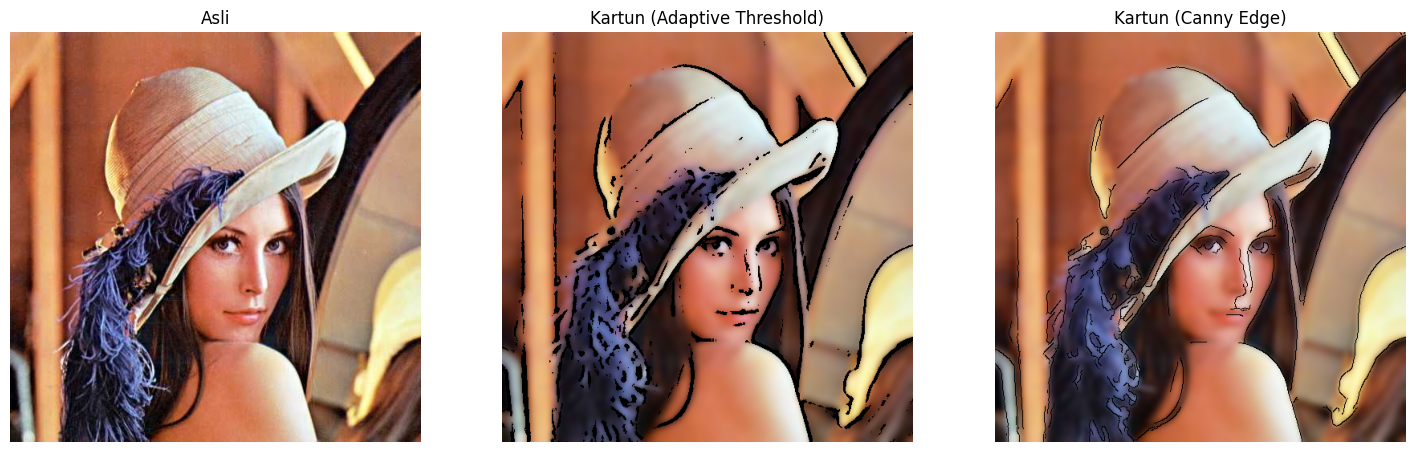

In [39]:
img = cv.imread(os.path.join(BASE, 'lena.jpg'))     # ganti dengan gambar yang kamu punya

kartun_adaptive = kartun(img, metode="adaptive")
kartun_canny    = kartun(img, metode="canny")

show_side_by_side([img, kartun_adaptive, kartun_canny],
                  ["Asli", "Kartun (Adaptive Threshold)", "Kartun (Canny Edge)"],
                  figsize=(18, 6))

### Fungsi `kartun(image)`
Fungsi menggabungkan tiga tahap:

1. **Penghalusan warna (Bilateral Filter).** Filter ini meratakan warna pada area yang intensitasnya mirip, tetapi mempertahankan batas antar objek karena mempertimbangkan perbedaan warna selain jarak piksel. Filter diulang beberapa kali agar area warna menjadi rata seperti blok warna pada kartun.

2. **Deteksi garis tepi.** Citra diubah ke grayscale dan diberi Median Blur untuk mengurangi noise, lalu garis tepi dideteksi dengan salah satu dari dua metode:
   - **Adaptive Thresholding:** ambang dihitung per area lokal sehingga menghasilkan garis tegas yang konsisten walaupun pencahayaan tidak merata.
   - **Canny Edge:** menghasilkan garis tepi tipis dan bersih, lalu dibalik agar garis berwarna hitam.

3. **Penggabungan.** Operasi logika `bitwise_and` antara citra warna halus dan mask garis tepi. Piksel dipertahankan di area mask putih dan menjadi hitam di tempat garis tepi, sehingga garis hitam menimpa area warna rata.

### Perbandingan hasil

| Aspek | Adaptive Threshold | Canny Edge |
|---|---|---|
| Ketebalan garis | Lebih tebal, mirip kartun | Lebih tipis |
| Detail tekstur | Lebih banyak garis kecil | Lebih bersih |
| Kecocokan | Efek kartun yang tegas | Efek sketsa halus |

### Kesimpulan
Efek kartun didapat dari kombinasi **warna yang rata** (Bilateral Filter) dan **garis tepi yang tegas** (Adaptive Threshold atau Canny). Kedua komponen digabungkan dengan operasi logika AND atau perkalian piksel sehingga garis hitam hanya muncul di batas objek, sedangkan area lainnya tetap berwarna halus.